In [1]:
# ============================================================
# CELLA 1 - Import e setup
# ============================================================
import sys
import os
import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.data import Data

from src.datasets.gqa_graph_dataset import GQAGraphDataset, build_node_vocab, build_rel_vocab
from src.models.gnn import GCNEmbeddingNet, GINEEmbeddingNet
from src.evaluation.retrieval import evaluate_retrieval, print_metrics


p:\Anaconda\envs\torch_new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from src.utils.gnnExplainer import *

In [3]:

# ============================================================
# Caricamento config e checkpoint GCN
# ============================================================
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gcn_config.yaml")
with open(config_path) as f:
    cfg_gcn = yaml.safe_load(f)

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path  = os.path.join(BASE_DIR, cfg_gcn["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gcn = checkpoint["node_vocab"]
rel_vocab_gcn  = checkpoint["rel_vocab"]

gcn_model = GCNEmbeddingNet(
    num_node_types=len(node_vocab_gcn) + 1,
    emb_dim=cfg_gcn["model"]["emb_dim"],
    hidden_dim=cfg_gcn["model"]["hidden_dim"],
    num_layers=cfg_gcn["model"]["num_layers"],
    dropout=cfg_gcn["model"]["dropout"],
    use_bbox=cfg_gcn["model"]["use_bbox"],
    node_emb_dim=cfg_gcn["model"]["node_emb_dim"],
).to(device)

gcn_model.load_state_dict(checkpoint["model_state_dict"])
gcn_model.eval()
print(f"GCN caricato da: {ckpt_path}")

gcn_wrapper = GCNWrapper(gcn_model).to(device)



GCN caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gcn20.pth


In [4]:

# ============================================================
# Caricamento config e checkpoint GINE
# ============================================================
config_path = os.path.join(BASE_DIR, "experiments", "configs", "gine_config.yaml")
with open(config_path) as f:
    cfg_gine = yaml.safe_load(f)

ckpt_path  = os.path.join(BASE_DIR, cfg_gine["training"]["checkpoint"])
checkpoint = torch.load(ckpt_path, map_location=device)

node_vocab_gine = checkpoint["node_vocab"]
rel_vocab_gine  = checkpoint["rel_vocab"]

gine_model = GINEEmbeddingNet(
    num_node_types=len(node_vocab_gine) + 1,
    edge_vocab_size=len(rel_vocab_gine),
    emb_dim=cfg_gine["model"]["emb_dim"],
    hidden_dim=cfg_gine["model"]["hidden_dim"],
    num_layers=cfg_gine["model"]["num_layers"],
    dropout=cfg_gine["model"]["dropout"],
    use_bbox=cfg_gine["model"]["use_bbox"],
    node_emb_dim=cfg_gine["model"]["node_emb_dim"],
).to(device)

gine_model.load_state_dict(checkpoint["model_state_dict"])
gine_model.eval()
print(f"GINE caricato da: {ckpt_path}")

gine_wrapper = GINEWrapper(gine_model).to(device)



GINE caricato da: p:\Uni\mujoco\dl26-projects\experiments/checkpoints/gnn20.pth


In [5]:

# ============================================================
# Dataset di validazione
# ============================================================
df_train = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["train_csv"]))
df_val   = pd.read_csv(os.path.join(BASE_DIR, cfg_gcn["data"]["val_csv"]))

all_labels = df_train["labels"].unique()
label2idx  = {l: i for i, l in enumerate(all_labels)}
idx2label  = {i: l for l, i in label2idx.items()}

df_train["labels"] = df_train["labels"].map(label2idx)
df_val["labels"]   = df_val["labels"].map(label2idx)

val_dataset_gcn = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab_gcn,
    rel_vocab=rel_vocab_gcn,
    label2idx=label2idx,
    idx2label=idx2label,
    use_bbox=cfg_gcn["model"]["use_bbox"],
)

val_dataset_gine = GQAGraphDataset(
    df=df_val,
    label_col="labels",
    node_vocab=node_vocab_gine,
    rel_vocab=rel_vocab_gine,
    label2idx=label2idx,
    idx2label=idx2label,
    use_bbox=cfg_gine["model"]["use_bbox"],
)

IMAGE_DIR = os.path.join(BASE_DIR, "data", "images")
print(f"Val dataset size: {len(val_dataset_gcn)}")



Val dataset size: 3208


In [6]:

# ============================================================
# Setup GNNExplainer per GCN e GINE
# ============================================================
explainer_gcn = Explainer(
    model=gcn_wrapper,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="regression",          # embedding, non classificazione
        task_level="graph",
        return_type="raw",
    ),
)

explainer_gine = Explainer(
    model=gine_wrapper,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict(
        mode="regression",
        task_level="graph",
        return_type="raw",
    ),
)



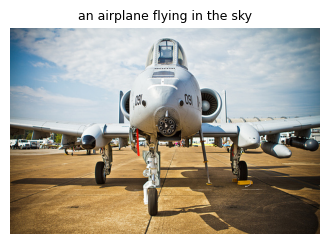

p:\Anaconda\envs\torch_new\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


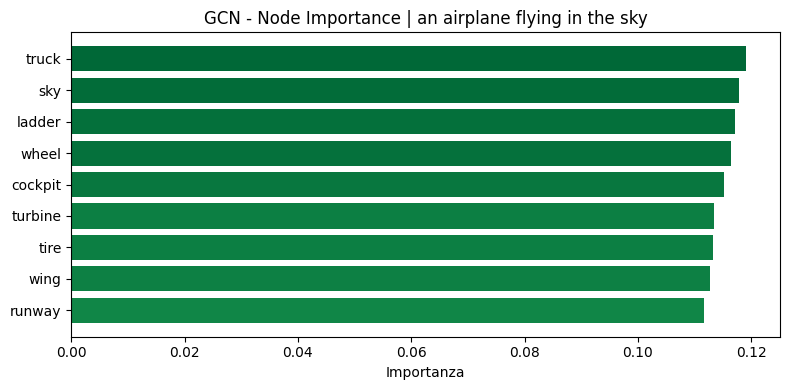

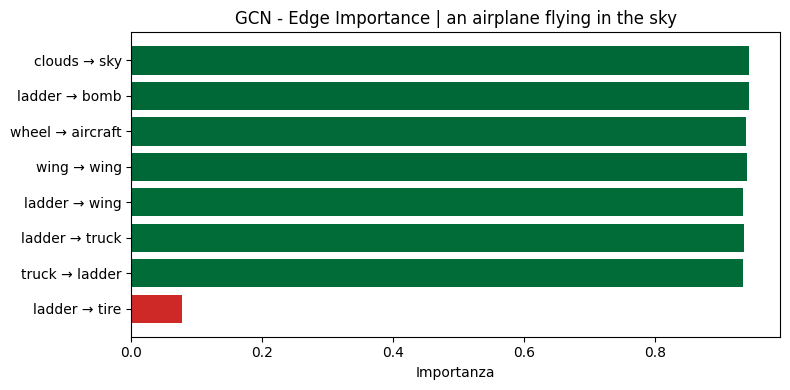

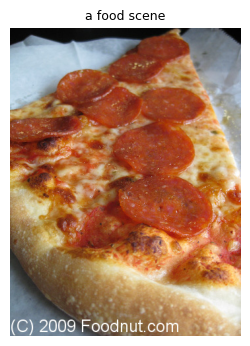

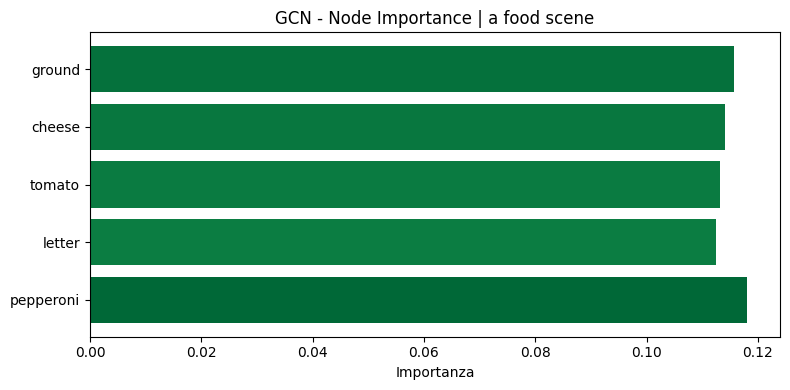

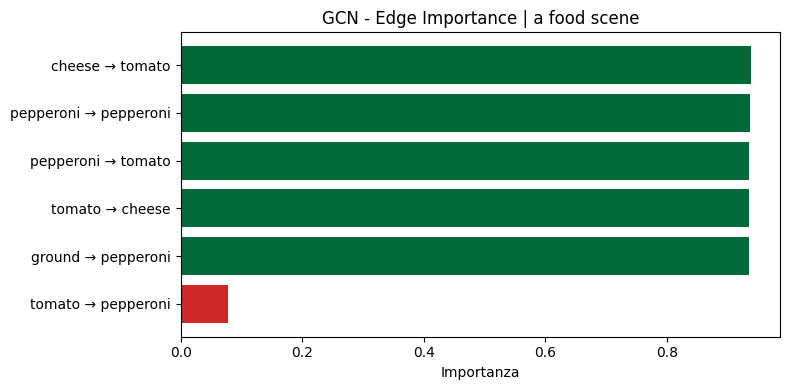

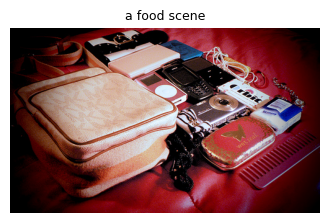

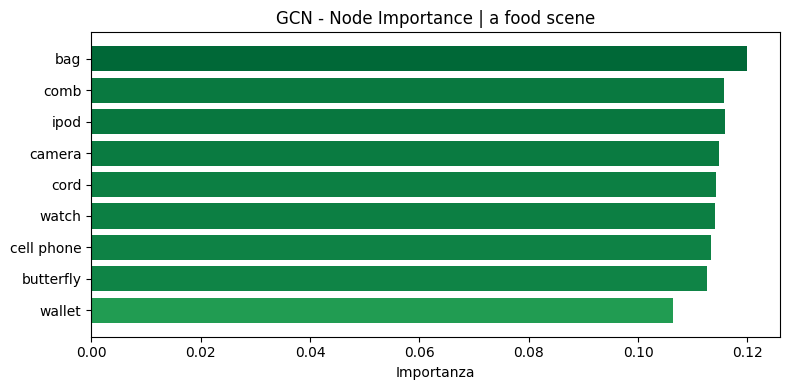

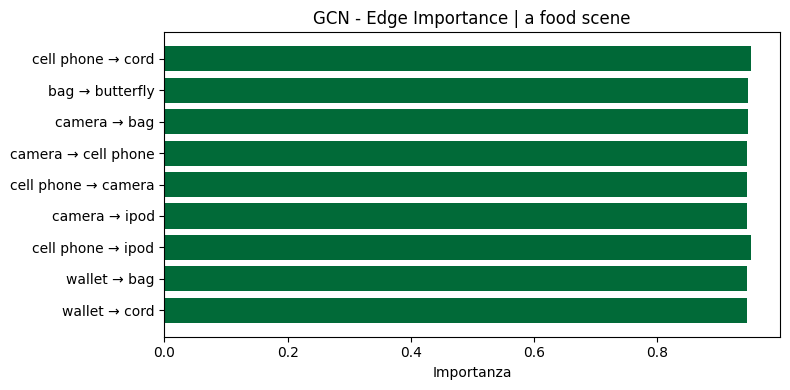

In [7]:

# ============================================================
#  GNNExplainer su GCN: analisi campioni casuali
# ============================================================
np.random.seed(40)
sample_indices = np.random.choice(len(val_dataset_gcn), size=3, replace=False)

for idx in sample_indices:
    data       = val_dataset_gcn[idx].to(device)
    node_names = get_node_names(data, node_vocab_gcn)
    label      = idx2label.get(int(data.y.item()), "?")
    image_id   = df_val.iloc[idx]["image_id"]

    # immagine
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    show_image(image_id, label, ax=ax)
    plt.show()

    # spiegazione GCN
    explanation = explainer_gcn(
        x=data.x,
        edge_index=data.edge_index,
    )

    plot_node_importance(
        explanation, node_names,
        title=f"GCN - Node Importance | {label}",
        topk=min(10, len(node_names))
    )
    plot_edge_importance(
        explanation, node_names, data,
        title=f"GCN - Edge Importance | {label}",
        topk=min(10, data.edge_index.size(1))
    )


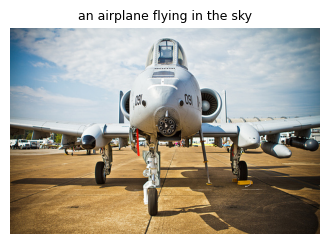

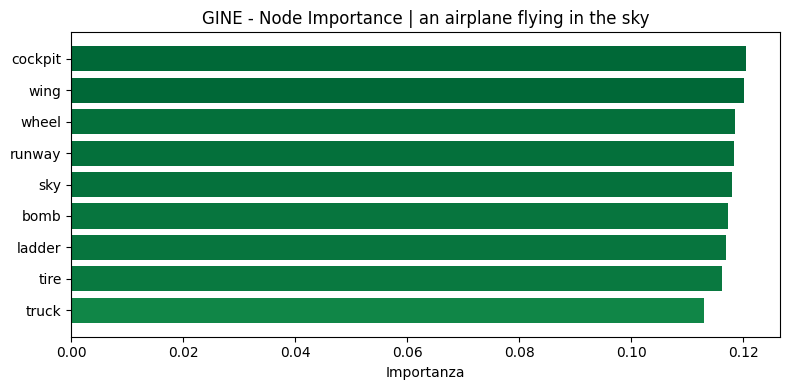

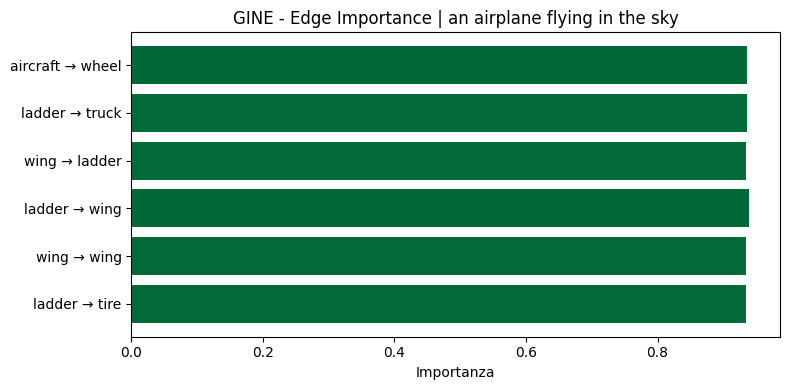

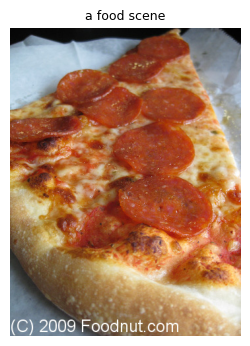

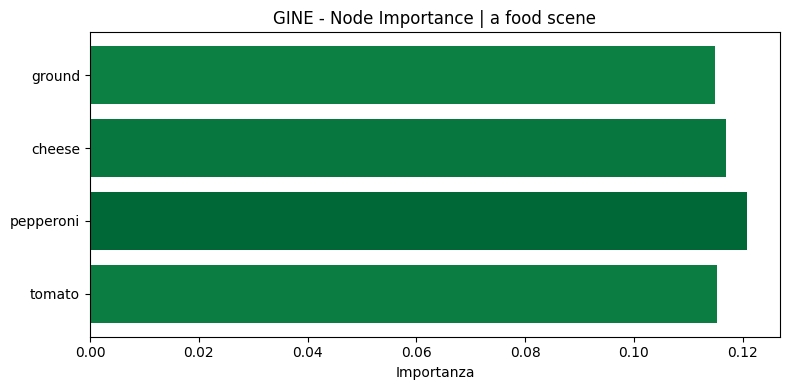

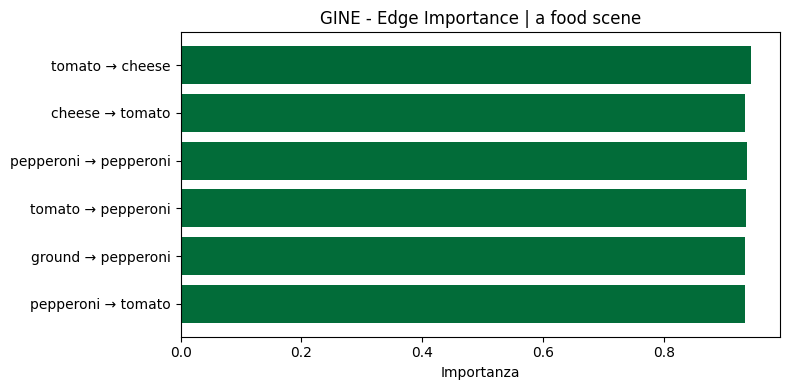

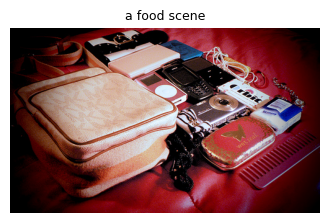

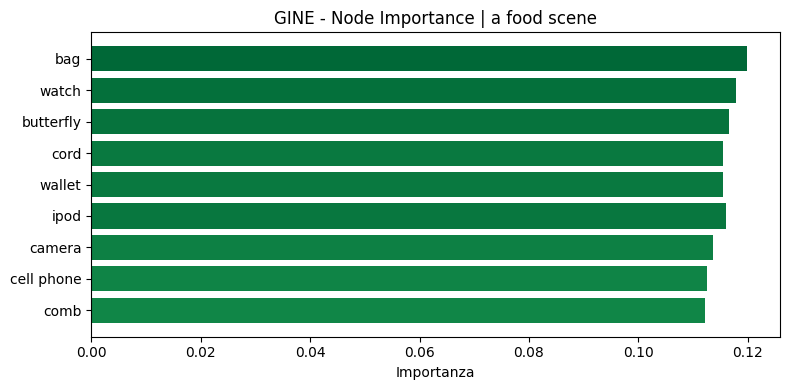

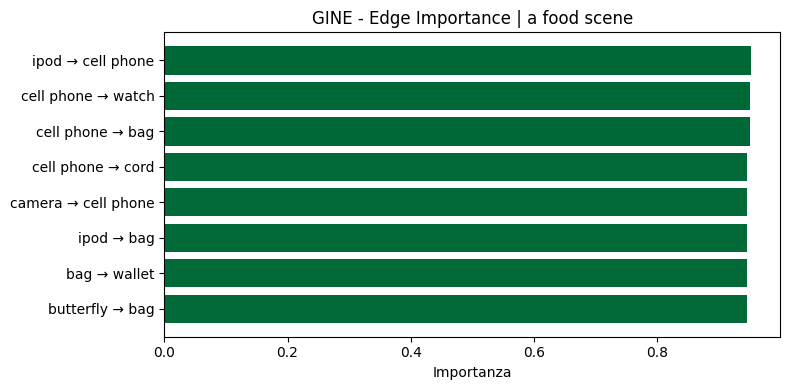

In [8]:

# ============================================================
# GNNExplainer su GINE: analisi campioni casuali
# ============================================================
for idx in sample_indices:
    data       = val_dataset_gine[idx].to(device)
    node_names = get_node_names(data, node_vocab_gine)
    label      = idx2label.get(int(data.y.item()), "?")
    image_id   = df_val.iloc[idx]["image_id"]

    # immagine
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    show_image(image_id, label, ax=ax)
    plt.show()

    # spiegazione GINE (richiede edge_attr)
    explanation = explainer_gine(
        x=data.x,
        edge_index=data.edge_index,
        edge_attr=data.edge_attr,
    )

    plot_node_importance(
        explanation, node_names,
        title=f"GINE - Node Importance | {label}",
        topk=min(10, len(node_names))
    )
    plot_edge_importance(
        explanation, node_names, data,
        title=f"GINE - Edge Importance | {label}",
        topk=min(10, data.edge_index.size(1))
    )


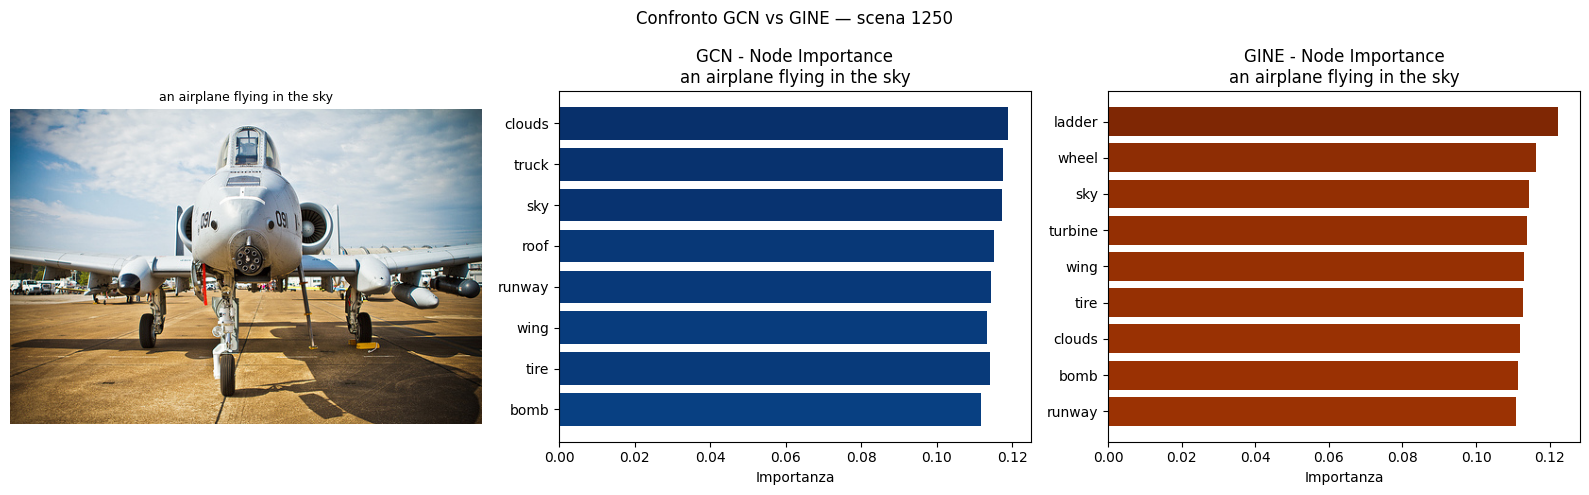

In [ ]:

# ============================================================
# Confronto GCN vs GINE su 3 campioni
# ============================================================
for idx in [int(i) for i in sample_indices[:3]]:
    label    = idx2label.get(int(val_dataset_gcn[idx].y.item()), "?")
    image_id = df_val.iloc[idx]["image_id"]
 
    data_gcn  = val_dataset_gcn[idx].to(device)
    data_gine = val_dataset_gine[idx].to(device)
 
    names_gcn  = get_node_names(data_gcn,  node_vocab_gcn)
    names_gine = get_node_names(data_gine, node_vocab_gine)
 
    exp_gcn  = explainer_gcn(x=data_gcn.x, edge_index=data_gcn.edge_index)
    exp_gine = explainer_gine(x=data_gine.x, edge_index=data_gine.edge_index,
                               edge_attr=data_gine.edge_attr)
 
    imp_gcn  = exp_gcn.node_mask.mean(dim=1).cpu().numpy()
    imp_gine = exp_gine.node_mask.mean(dim=1).cpu().numpy()
 
    top_gcn  = np.argsort(imp_gcn)[::-1][:10]
    top_gine = np.argsort(imp_gine)[::-1][:10]
 
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
    # immagine
    show_image(image_id, label, ax=axes[0])
 
    # GCN
    axes[1].barh(
        [names_gcn[i]  for i in top_gcn][::-1],
        imp_gcn[top_gcn][::-1],
        color=cm.Blues(imp_gcn[top_gcn][::-1] / (imp_gcn.max() + 1e-8))
    )
    axes[1].set_title(f"GCN - Node Importance\n{label}")
    axes[1].set_xlabel("Importanza")
 
    # GINE
    axes[2].barh(
        [names_gine[i] for i in top_gine][::-1],
        imp_gine[top_gine][::-1],
        color=cm.Oranges(imp_gine[top_gine][::-1] / (imp_gine.max() + 1e-8))
    )
    axes[2].set_title(f"GINE - Node Importance\n{label}")
    axes[2].set_xlabel("Importanza")
 
    plt.suptitle(f"Confronto GCN vs GINE — scena {idx}", fontsize=12)
    plt.tight_layout()
    plt.show()
 